# Machine Learning Model Comparison Experiment
This notebook explores several machine learning algorithms for **classification and regression** tasks. The goal is to analyze how different hyperparameters influence model performance through visualizations and interpret the results.

## Goal of the Experiment
In this experiment we compare several classical machine learning algorithms:

- KNN
- Decision Trees
- Random Forest
- Support Vector Machines

For each algorithm we vary important hyperparameters and visualize how they affect performance. The classification task uses the **body performance dataset**, while the regression task uses the **car dataset**.

## Import Libraries
This cell imports all libraries required for data processing, machine learning models, and visualization.

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR


## Load the Datasets
We load both datasets. The **body performance dataset** will be used for classification and the **car dataset** will be used for regression.

In [6]:

body = pd.read_csv("../Datasets/Hyperparameter1/bodyPerformance.csv")
cars = pd.read_csv('../Datasets/Hyperparameter1/Dataset.csv')


## Data Cleaning and Preparation
Here we clean the datasets, remove unnecessary columns, encode categorical variables and prepare them for machine learning models.

In [7]:

# Regression dataset preparation
cars = cars.copy()

# Remove unnecessary columns
cars = cars.drop(columns=['Unnamed: 0','Id','brand','full_model_name','model_name','city'], errors='ignore')

# Convert categorical variables
cars = pd.get_dummies(cars, drop_first=True)

# Replace infinity values with NaN
cars.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove rows containing NaN
cars.dropna(inplace=True)

# Define target and features
y_reg = cars['price']
X_reg = cars.drop(columns=['price'])


## Train Test Split
We divide the datasets into training and testing sets so that we can evaluate the models on unseen data.

In [8]:

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler = StandardScaler()
Xc_train = scaler.fit_transform(Xc_train)
Xc_test = scaler.transform(Xc_test)
Xr_train = scaler.fit_transform(Xr_train)
Xr_test = scaler.transform(Xr_test)


## KNN Classifier
We test how the number of neighbors influences the classification accuracy.

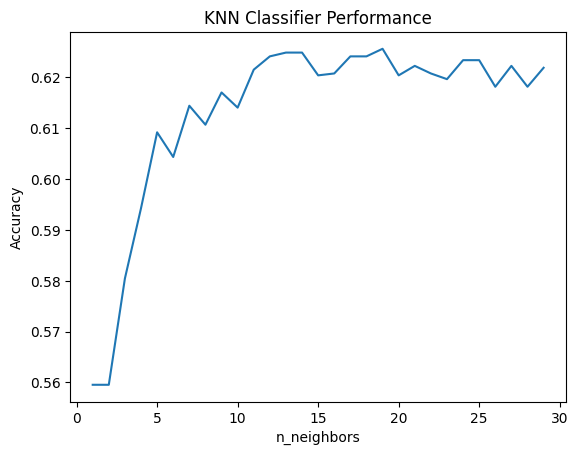

In [9]:

neighbors = range(1,30)
acc = []

for n in neighbors:
    model = KNeighborsClassifier(n_neighbors=n)
    model.fit(Xc_train,yc_train)
    pred = model.predict(Xc_test)
    acc.append(accuracy_score(yc_test,pred))

plt.plot(neighbors,acc)
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.title("KNN Classifier Performance")
plt.show()


### Conclusion
The graph shows how the number of neighbors affects classification accuracy. Very small values may overfit while larger values smooth the decision boundary.

## KNN Regressor
We analyze how the number of neighbors affects regression performance measured by Mean Squared Error.

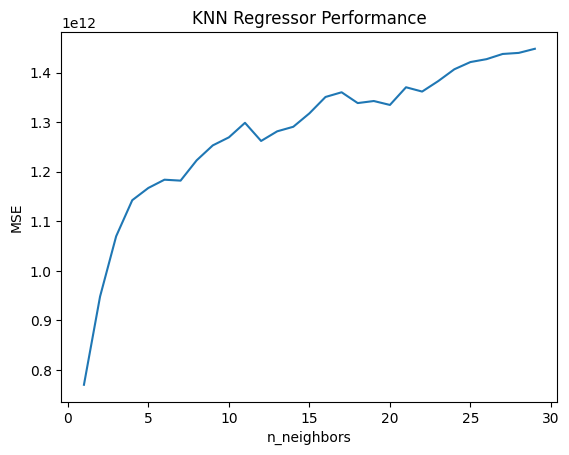

In [10]:

mse = []

for n in neighbors:
    model = KNeighborsRegressor(n_neighbors=n)
    model.fit(Xr_train,yr_train)
    pred = model.predict(Xr_test)
    mse.append(mean_squared_error(yr_test,pred))

plt.plot(neighbors,mse)
plt.xlabel("n_neighbors")
plt.ylabel("MSE")
plt.title("KNN Regressor Performance")
plt.show()


### Conclusion
The optimal number of neighbors minimizes the Mean Squared Error. Too few neighbors may cause overfitting while too many may oversmooth predictions.

## Decision Tree Classifier Heatmaps
We evaluate combinations of **max_depth** and **max_features** using two criteria: gini and entropy.

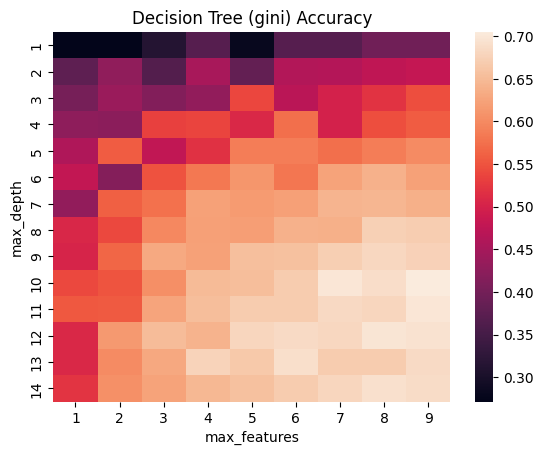

In [11]:

depths = range(1,15)
features = range(1, min(10,X_class.shape[1]))

results = np.zeros((len(depths),len(features)))

for i,d in enumerate(depths):
    for j,f in enumerate(features):
        model = DecisionTreeClassifier(max_depth=d,max_features=f,criterion='gini')
        model.fit(Xc_train,yc_train)
        pred = model.predict(Xc_test)
        results[i,j] = accuracy_score(yc_test,pred)

sns.heatmap(results,xticklabels=features,yticklabels=depths)
plt.xlabel("max_features")
plt.ylabel("max_depth")
plt.title("Decision Tree (gini) Accuracy")
plt.show()


### Conclusion
The heatmap shows which combinations of depth and feature usage produce the highest accuracy.

## Random Forest Classifier
We analyze how the number of trees influences performance using gini and entropy criteria.

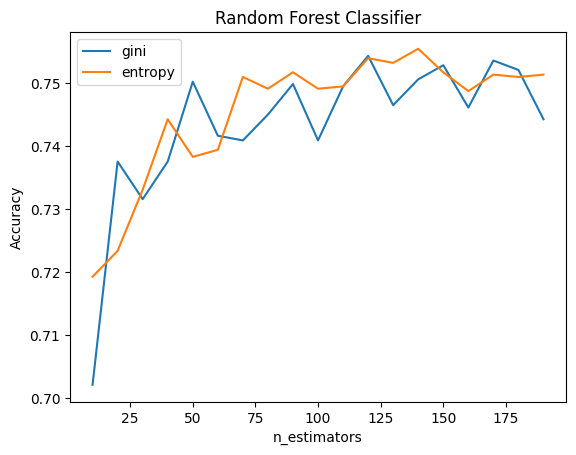

In [12]:

estimators = range(10,200,10)
gini_scores = []
entropy_scores = []

for e in estimators:
    gini = RandomForestClassifier(n_estimators=e,criterion='gini')
    gini.fit(Xc_train,yc_train)
    gini_scores.append(accuracy_score(yc_test,gini.predict(Xc_test)))
    
    ent = RandomForestClassifier(n_estimators=e,criterion='entropy')
    ent.fit(Xc_train,yc_train)
    entropy_scores.append(accuracy_score(yc_test,ent.predict(Xc_test)))

plt.plot(estimators,gini_scores,label='gini')
plt.plot(estimators,entropy_scores,label='entropy')
plt.legend()
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest Classifier")
plt.show()


### Conclusion
Increasing the number of trees generally stabilizes performance and improves generalization.

## SVC Model
We compare different kernels and observe how parameter C affects classification accuracy.

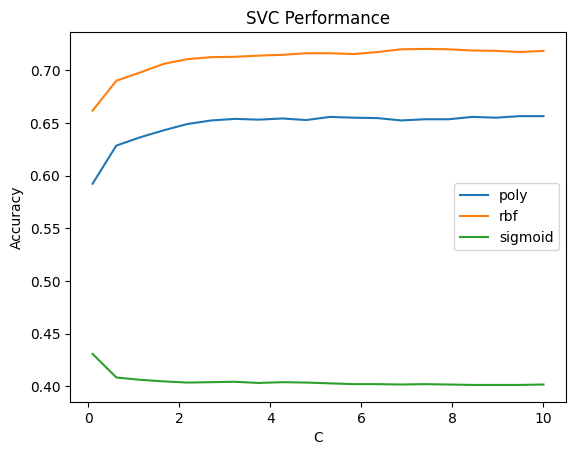

In [13]:

C_values = np.linspace(0.1,10,20)
kernels = ['poly','rbf','sigmoid']

for k in kernels:
    scores = []
    for c in C_values:
        model = SVC(kernel=k,C=c)
        model.fit(Xc_train,yc_train)
        pred = model.predict(Xc_test)
        scores.append(accuracy_score(yc_test,pred))
        
    plt.plot(C_values,scores,label=k)

plt.legend()
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVC Performance")
plt.show()


### Conclusion
Different kernels behave differently depending on the data structure. The parameter C controls the balance between margin size and classification errors.

## Final Conclusion
This experiment compared several machine learning algorithms for both classification and regression tasks. We explored how hyperparameters influence performance and visualized their effects through line plots and heatmaps.

Key observations:

- KNN performance strongly depends on the number of neighbors.
- Decision Trees are sensitive to depth and feature selection.
- Random Forest improves stability by combining multiple trees.
- Support Vector Machines depend heavily on kernel choice and parameter C.

Overall, the experiment demonstrates the importance of hyperparameter tuning and visualization when selecting machine learning models.